# HypotheSAEs Quickstart: Local

This notebook demonstrates basic usage of HypotheSAEs on a sample of the Yelp review 8104set, entirely using local compute. You will need a GPU*.
- We use a sentence-transformers model for text embeddings. This can run on CPU or GPU (if a cuda device is available, it will use GPU).
- We use a large language model loaded in vLLM for hypothesis generation and text annotation. This requires GPU.
- This notebook uses `Qwen/Qwen3-32B-AWQ`. (If your GPU doesn't support this model or have enough memory, you can use a different model.)
- Takes about 80 minutes to run using an NVIDIA A6000. The slowest step is hypothesis evaluation on the heldout set, which requires lots of LLM annotation.

*It's possible you can get some smaller LLMs to run on CPU, perhaps with some modifications to the vLLM config, but it's not tested.

In [1]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2



import os
os.environ['CUDA_VISIBLE_DEVICES'] = '6' # Use single GPU to avoid distributed training issues

import numpy as np
import pandas as pd

from hypothesaes.quickstart import train_sae, interpret_sae, generate_hypotheses, evaluate_hypotheses
from hypothesaes.embedding import get_local_embeddings
from hypothesaes.llm_local import get_vllm_engine

**0. Load data**

The dataset we're using here is a subset of 20K Yelp reviews, with 2K reviews used for validation (during SAE training).

The target variable is the `stars` column, which is a rating between 1 and 5. We treat this as a regression task.

There are also 2K reviews used for holdout evaluation, which we'll use at the end of the notebook.

In [2]:
current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    prefix = "../"
else:
    prefix = "./"

base_dir = os.path.join(prefix, "demo_data")
train_df = pd.read_json(os.path.join(base_dir, "yelp-demo-train-20K.json"), lines=True)
val_df = pd.read_json(os.path.join(base_dir, "yelp-demo-val-2K.json"), lines=True)

texts = train_df['text'].tolist()
labels = train_df['stars'].values
val_texts = val_df['text'].tolist() # These are only used for early stopping of SAE training, so we don't need labels.

**1. Compute text embeddings for your 8104set**

We'll compute text embeddings for a training set, and optionally a validation set. The validation embeddings are used for SAE eval and early-stopping during training.

Embeddings will be stored in the `emb_cache` directory (or `os.environ["EMB_CACHE_DIR"]` if you set it) using the `cache_name` parameter, so you only need to compute embeddings once.

We will compute embeddings using a good sentence-transformers model, `nomic-ai/modernbert-embed-base` (smaller models like `sentence-transformers/all-roberta-large-v1` should also work well, and may fit on GPUs with less memory).

In [3]:
EMBEDDER = "nomic-ai/modernbert-embed-base"
CACHE_NAME = f"yelp_quickstart_local_{EMBEDDER}"

text2embedding = get_local_embeddings(texts + val_texts, model=EMBEDDER, batch_size=128, cache_name=CACHE_NAME)
embeddings = np.stack([text2embedding[text] for text in texts])

train_embeddings = np.stack([text2embedding[text] for text in texts])
val_embeddings = np.stack([text2embedding[text] for text in val_texts])

Loading embedding chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded 22000 embeddings in 0.3s


**2. Train SAE**

We will train a Matryoshka SAE with $M=256$, $k=8$, and $\text{prefix\_lengths} = [32, 256]$.  

With the Matryoshka loss, the SAE will learn to reconstruct the input from (1) just the first 32 neurons, and (2) all 256 neurons.  
This will produce 32 coarse-grained features, and 224 finer-grained features.  

See the README for more 8etails about selecting SAE hyperparameters. 





In [4]:
checkpoint_dir = os.path.join(prefix, "checkpoints", CACHE_NAME)
sae = train_sae(embeddings=train_embeddings, M=256, K=8, matryoshka_prefix_lengths=[32, 256], checkpoint_dir=checkpoint_dir, val_embeddings=val_embeddings)

Loaded model from ../checkpoints/yelp_quickstart_local_nomic-ai/modernbert-embed-base/SAE_matryoshka_M=256_K=8_prefixes=32-256.pt onto device cuda


**3. Interpret neurons**

This step will load a local LLM in vLLM, and use it to interpret a few random neurons in the SAE.  
This is to ensure that the local LLM is working and the interpretations look reasonable, if not perfect.

In [5]:
'''
Some vLLM notes:
- When running in notebook, it's best to use the same interpreter and annotator model;
  this is because there is some memory overhead when switching models (ie we can't fully free GPU memory).
- We set `gpu_memory_utilization=0.85`, which avoids OOMs with Qwen3-32B-AWQ on an A6000.
  You may want to adjust this depending on your hardware/model.
- You can increase `tensor_parallel_size` to use multiple GPUs on the same node.
  See vLLM docs: https://docs.vllm.ai/en/latest/serving/distributed_serving.html
'''
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3' 

INTERPRETER_MODEL = ANNOTATOR_MODEL = "Qwen/Qwen3-8B-AWQ"

engine = get_vllm_engine(
    INTERPRETER_MODEL, 
    gpu_memory_utilization=0.85,
    tensor_parallel_size=1,
)

Loading Qwen/Qwen3-8B-AWQ in vLLM...


`torch_dtype` is deprecated! Use `dtype` instead!


(EngineCore_0 pid=3994910) WARNING 09-09 16:57:15 [topk_topp_sampler.py:61] FlashInfer is not available. Falling back to the PyTorch-native implementation of top-p & top-k sampling. For the best performance, please install FlashInfer.


Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:00<00:00,  1.27it/s]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:01<00:00,  1.77it/s]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:01<00:00,  1.67it/s]
(EngineCore_0 pid=3994910) 
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 67/67 [00:05<00:00, 11.99it/s]


Loaded Qwen/Qwen3-8B-AWQ with dtype: torch.float16 (took 48.6s)


In [6]:
# This instruction will be included in the neuron interpretation prompt.
# The below instructions are specific to Yelp, but you can customize this for your task.
# If you don't pass in task-specific instructions, there is a generic instruction (see src/interpret_neurons.py);
# task-specific instructions are optional, but they help produce hypotheses at the desired level of specificity.

TASK_SPECIFIC_INSTRUCTIONS = """All of the texts are reviews of restaurants on Yelp.
Features should describe a specific aspect of the review. For example:
- "mentions long wait times to receive service"
- "praises how a dish was cooked, with phrases like 'perfect medium-rare'\""""

# Interpret random neurons
results = interpret_sae(
    texts=texts,
    embeddings=train_embeddings,
    sae=sae,
    interpreter_model=INTERPRETER_MODEL,
    n_random_neurons=5,
    print_examples_n=3,
    task_specific_instructions=TASK_SPECIFIC_INSTRUCTIONS
)

Computing activations (batchsize=16384):   0%|          | 0/2 [00:00<?, ?it/s]

Activations shape: (20000, 256)


Adding requests:   0%|          | 0/5 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/5 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Neuron 163 (0.7% active, from SAE M=256, K=8): mentions the food being prepared with specific cooking methods, such as frying or grilling

Top activating examples:
1. Excellent food, great service, so-so location (I've actually had to wade outside with my pant legs rolled up and my shoes under my arm because a heavy rain flooded the entire restaurant.)
2. Besel replaced the pipes in my newly purchased 1958 house after a leak. They responded immediately. I highly recommend them. The work done was amazing. They showed up on time. Left everything clean. Did their best to minimize disruption to our lives. The work was done in the promised time frame   Dave, Steve and Sean were professional and knowledgeable. Working with the owner Mike and George was so easy. We will use them again for any plumbing needs. I would rate them higher than five stars if I could.
3. I came here since it was a restaurant on The Hill.  It was starting to rain so I had to make a decision quick before I got soaked.

**4. Generate hypotheses**

Generate hypotheses which are predictive of the target variable.  

We use the local LLM to generate interpretations and then estimate each interpretation's fidelity by annotating texts with the interpretation.

Here, we select neurons after ranking them by correlation with the target variable. See `src/select_neurons.py` for more 8etails and other selection methods (e.g., Lasso).

This cell outputs a dataframe with the following columns:
- `neuron_idx`: The index of the neuron in the SAE (if you're using multiple SAEs, this will be a global index across all of them).
- `source_sae`: The SAE that the neuron was selected from.
- `target_{selection_method}`: The predictiveness of the neuron for the target variable, using the selected `selection_method`.
- `interpretation`: The natural language interpretation of the neuron.
- `interp_fidelity_score`: The F1 fidelity score for how well the neuron's interpretation actually corresponds to its activation pattern.

In [7]:
selection_method = "correlation"
results = generate_hypotheses(
    texts=texts,
    labels=labels,
    embeddings=embeddings,
    sae=sae,
    interpreter_model=INTERPRETER_MODEL,
    annotator_model=ANNOTATOR_MODEL,
    selection_method=selection_method,
    n_selected_neurons=20,
    n_candidate_interpretations=1,
    task_specific_instructions=TASK_SPECIFIC_INSTRUCTIONS
)

print("\nMost predictive features of Yelp reviews:")
pd.set_option('display.max_colwidth', None)
display(results.sort_values(by=f"target_{selection_method}", ascending=False))
pd.reset_option('display.max_colwidth')

Embeddings shape: (20000, 768)


Computing activations (batchsize=16384):   0%|          | 0/2 [00:00<?, ?it/s]

Activations shape: (20000, 256)

Step 1: Selecting top 20 predictive neurons

Step 2: Interpreting selected neurons


Adding requests:   0%|          | 0/20 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/20 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]


Step 3: Scoring Interpretations
Found 0 cached items; annotating 2000 uncached items


Adding requests:   0%|          | 0/2000 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/2000 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s…


Most predictive features of Yelp reviews:


,neuron_idx,source_sae,target_correlation,interpretation,f1_fidelity_score
4,13,"(SAE_0, 256, 8)",0.257274,mentions servers providing exceptional assistance with personal customer needs beyond basic service,0.603429
6,8,"(SAE_0, 256, 8)",0.225583,mentions the staff being friendly and professional,0.700000
7,25,"(SAE_0, 256, 8)",0.202389,mentions fresh ingredients,0.460800
14,22,"(SAE_0, 256, 8)",0.125264,describes the texture and flavor of the food in detail,0.387451
16,227,"(SAE_0, 256, 8)",0.117041,mentions specific dishes with positive adjectives,0.459375
17,32,"(SAE_0, 256, 8)",0.116819,"mentions specific local or homemade ingredients like cholla buds, hibiscus flowers, or empanadas, which are praised as fresh or delicious",0.181818
19,148,"(SAE_0, 256, 8)",0.114213,mentions the food being described as 'the best' in the review,0.682899
18,155,"(SAE_0, 256, 8)",-0.116472,mentions inability to reach the restaurant by phone,0.611111
15,2,"(SAE_0, 256, 8)",-0.120087,mentions price being excessively high for the quantity of food,0.852558
13,235,"(SAE_0, 256, 8)",-0.125729,mentions being ignored by staff,0.630303


**5. Evaluate held-out generalization**

Finally, we evaluate whether these are good hypotheses by testing whether their natural language interpretations can predict the target variable.  

We compute annotations for each hypothesized concept on a holdout set (not seen during SAE training & feature selection).  
This step uses the same local LLM as the one used to generate interpretations (though, for Qwen models, we set `enable_thinking=False` for annotation to improve speed).

After annotation, we output a dataframe with the following columns:
- `hypothesis`: The natural language hypothesis (which came from interpreting a predictive neuron in the SAE)
- `separation_score`: How much the target variable differs when the concept is present vs. absent (i.e., $E[Y\mid\text{concept} = 1] - E[Y\mid\text{concept} = 0]$).
- `separation_pvalue`: The t-test p-value of the null hypothesis that the separation score is 0 (i.e., the concept is not associated with the target variable).
- `regression_coef`: The coefficient of the concept in a multivariate linear regression of the target variable on all concepts.
- `regression_pval`: The p-value of the null hypothesis that the regression coefficient is 0.
- `feature_prevalence`: The fraction of examples that contain the concept.

Additionally, we output the evaluation metrics used in the paper:
- Significant hypotheses: the number of hypotheses that are significant in the multivariate regression at a specified significance level (default $0.1$) after Bonferroni correction. You can pass in a different significance level using the `corrected_pval_threshold` parameter.
- AUC or $R^2$: how well the hypotheses collectively predict the target variable in the multivariate regression.


In [8]:
holdout_df = pd.read_json(os.path.join(base_dir, "yelp-demo-holdout-2K.json"), lines=True)
holdout_texts = holdout_df['text'].tolist()
holdout_labels = holdout_df['stars'].values

metrics, evaluation_df = evaluate_hypotheses(
    hypotheses_df=results,
    texts=holdout_texts,
    labels=holdout_labels,
    annotator_model=ANNOTATOR_MODEL,
)

pd.set_option('display.max_colwidth', None)
display(evaluation_df)
pd.reset_option('display.max_colwidth')

print("\nHoldout Set Metrics:")
print(f"R² Score: {metrics['r2']:.3f}")
print(f"Significant hypotheses: {metrics['Significant'][0]}/{metrics['Significant'][1]} " 
      f"(p < {metrics['Significant'][2]:.3e})")

Step 1: Annotating texts with 20 hypotheses
Found 0 cached items; annotating 40000 uncached items


Adding requests:   0%|          | 0/40000 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/40000 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/…

Step 2: Computing predictiveness of hypothesis annotations


,hypothesis,separation_score,separation_pval,regression_coef,regression_pval,feature_prevalence
16,mentions specific dishes with positive adjectives,1.873034,3.674493e-201,0.718021,7.502694e-50,0.7115
4,mentions servers providing exceptional assistance with personal customer needs beyond basic service,1.119037,6.353366e-14,0.381395,4.552992e-06,0.0455
19,mentions the food being described as 'the best' in the review,1.093237,7.116561e-42,0.333674,2.288180e-13,0.1745
6,mentions the staff being friendly and professional,1.013988,1.575756e-50,0.156481,1.153202e-04,0.2800
7,mentions fresh ingredients,0.949836,1.197184e-53,0.063155,1.287236e-01,0.4200
17,"mentions specific local or homemade ingredients like cholla buds, hibiscus flowers, or empanadas, which are praised as fresh or delicious",0.455518,2.174043e-02,0.033650,7.499332e-01,0.0255
14,describes the texture and flavor of the food in detail,0.161418,2.640851e-02,-0.024809,5.667107e-01,0.2455
11,mentions food poisoning,-0.737013,9.934872e-31,-0.078513,5.653556e-02,0.3655
15,mentions price being excessively high for the quantity of food,-1.249720,7.263068e-33,-0.301379,3.193986e-07,0.0955
2,mentions the food being overrated but the service is good,-1.316736,2.893832e-15,-0.101054,2.713696e-01,0.0360



Holdout Set Metrics:
R² Score: 0.729
Significant hypotheses: 9/20 (p < 5.000e-03)


In [16]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, t
import pandas as pd
import numpy as np

# ------------------------------
# 1. 生成 holdout embeddings
# ------------------------------
holdout_text2embedding = get_local_embeddings(
    holdout_texts,
    model=EMBEDDER,
    batch_size=128,
    cache_name=f"{CACHE_NAME}_holdout"
)
holdout_embeddings = np.stack([holdout_text2embedding[text] for text in holdout_texts])

# ------------------------------
# 2. 生成每条假设 embedding
# ------------------------------
hypothesis_texts = results['interpretation'].tolist()
hypothesis_embeddings_dict = get_local_embeddings(
    hypothesis_texts,
    model=EMBEDDER,
    batch_size=128,
    cache_name=f"{CACHE_NAME}_hypotheses"
)
hypothesis_embeddings = np.stack([hypothesis_embeddings_dict[h] for h in hypothesis_texts])

# ------------------------------
# 3. 计算 holdout 文本与假设的 cosine similarity
# ------------------------------
cos_sim_matrix = cosine_similarity(holdout_embeddings, hypothesis_embeddings)
pseudo_annotations = pd.DataFrame(cos_sim_matrix, columns=hypothesis_texts)

# ------------------------------
# 4. 计算 embedding-based pseudo-annotation 与 LLM regression_coef 的整体相关性
# ------------------------------
pseudo_mean = pseudo_annotations.mean(axis=0).values
llm_strength = evaluation_df['regression_coef'].values

min_len = min(len(pseudo_mean), len(llm_strength))
pseudo_vals = pseudo_mean[:min_len]
llm_vals = llm_strength[:min_len]

if len(pseudo_vals) >= 2:
    corr, _ = pearsonr(pseudo_vals, llm_vals)
    print(f"\nOverall Pearson correlation between embedding-based pseudo-annotations and LLM regression_coef: {corr:.3f}")
else:
    print("Not enough hypotheses to compute Pearson correlation.")

# ------------------------------
# 5. 函数：embedding-based pseudo-annotation 预测性评估
# ------------------------------
def evaluate_pseudo_annotations(hypotheses_df, pseudo_annotations, labels):
    n_texts, n_hypotheses = pseudo_annotations.shape
    evaluation_records = []

    for i, h in enumerate(hypotheses_df['interpretation']):
        X = pseudo_annotations.iloc[:, i].values.reshape(-1, 1)
        y = labels

        reg = LinearRegression().fit(X, y)
        coef = reg.coef_[0]
        y_pred = reg.predict(X)
        residuals = y - y_pred
        dof = X.shape[0] - 2
        se = np.sqrt(np.sum(residuals**2) / dof) / np.std(X[:,0], ddof=1)
        t_stat = coef / se
        p_val = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))
        feature_prevalence = X.mean()

        evaluation_records.append({
            'hypothesis': h,
            'regression_coef': coef,
            'regression_pval': p_val,
            'feature_prevalence': feature_prevalence
        })

    evaluation_df_emb = pd.DataFrame(evaluation_records)
    significant_count = (evaluation_df_emb['regression_pval'] < 0.05).sum()

    # 多元回归计算整体 R²
    reg_all = LinearRegression().fit(pseudo_annotations.values, labels)
    r2 = reg_all.score(pseudo_annotations.values, labels)

    metrics_emb = {
        'r2': r2,
        'Significant': (significant_count, n_hypotheses, 0.05)
    }

    return metrics_emb, evaluation_df_emb

# ------------------------------
# 6. 运行 embedding-based 预测性评估
# ------------------------------
metrics_emb, evaluation_df_emb = evaluate_pseudo_annotations(
    hypotheses_df=results,
    pseudo_annotations=pseudo_annotations,
    labels=holdout_labels
)

pd.set_option('display.max_colwidth', None)
display(evaluation_df_emb)
pd.reset_option('display.max_colwidth')

print("\nHoldout Set Metrics using embedding-based pseudo-annotations:")
print(f"R² Score: {metrics_emb['r2']:.3f}")
print(f"Significant hypotheses: {metrics_emb['Significant'][0]}/{metrics_emb['Significant'][1]} "
      f"(p < {metrics_emb['Significant'][2]:.3e})")


Loading embedding chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Loaded 2000 embeddings in 0.0s


Loading embedding chunks:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded 36 embeddings in 0.0s

Overall Pearson correlation between embedding-based pseudo-annotations and LLM regression_coef: -0.024


,hypothesis,regression_coef,regression_pval,feature_prevalence
0,mentions food being so bad that the reviewer got sick or food poisoning,-13.956038,0.650873,0.579932
1,mentions rude or unhelpful service staff,-14.086376,0.552082,0.567142
2,mentions the food being overrated but the service is good,-4.299923,0.887246,0.683828
3,mentions specific complaints about menu items not being available or not matching their description,-15.573898,0.649702,0.559781
4,mentions servers providing exceptional assistance with personal customer needs beyond basic service,-0.466420,0.989473,0.560618
5,mentions long wait times to receive service,-12.337691,0.647942,0.546497
6,mentions the staff being friendly and professional,1.350796,0.965790,0.602570
7,mentions fresh ingredients,10.302256,0.748118,0.604641
8,mentions the food being described with specific negative aspects like 'soggy' or 'chewy',-12.431215,0.681592,0.570978
9,mentions service staff being rude or disrespectful to customers,-14.467690,0.537801,0.571812



Holdout Set Metrics using embedding-based pseudo-annotations:
R² Score: 0.739
Significant hypotheses: 0/20 (p < 5.000e-02)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from scipy.stats import t
from sklearn.preprocessing import StandardScaler

# ------------------------------
# Function: Evaluate hypothesis predictiveness using standardized embedding-based pseudo-annotations
# ------------------------------
def evaluate_pseudo_annotations_scaled(hypotheses_df, pseudo_annotations, labels):
    """
    hypotheses_df: results DataFrame
    pseudo_annotations: DataFrame, shape = (n_texts, n_hypotheses)
    labels: ndarray, shape = (n_texts,), true labels (stars)
    
    Returns:
        metrics: dict containing R² and number of significant hypotheses
        evaluation_df: DataFrame containing regression coefficient, p-value, and mean similarity for each hypothesis
    """
    n_texts, n_hypotheses = pseudo_annotations.shape
    evaluation_records = []
    
    # Standardize each pseudo-annotation column
    scaler = StandardScaler()
    pseudo_scaled = pd.DataFrame(scaler.fit_transform(pseudo_annotations), columns=pseudo_annotations.columns)
    
    for i, h in enumerate(hypotheses_df['interpretation']):
        X = pseudo_scaled.iloc[:, i].values.reshape(-1, 1)  # standardized pseudo-annotation
        y = labels
        
        # Linear regression
        reg = LinearRegression().fit(X, y)
        coef = reg.coef_[0]
        y_pred = reg.predict(X)
        residuals = y - y_pred
        dof = X.shape[0] - 2
        se = np.sqrt(np.sum(residuals**2) / dof) / np.std(X[:,0], ddof=1)
        t_stat = coef / se
        p_val = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))
        
        feature_prevalence = pseudo_annotations.iloc[:, i].mean()  # original mean
        
        evaluation_records.append({
            'hypothesis': h,
            'regression_coef': coef,
            'regression_pval': p_val,
            'feature_prevalence': feature_prevalence
        })
    
    evaluation_df_emb = pd.DataFrame(evaluation_records)
    
    # Count significant hypotheses
    significant_count = (evaluation_df_emb['regression_pval'] < 0.05).sum()
    
    # Multivariate regression on all standardized pseudo-annotations to compute overall R²
    reg_all = LinearRegression().fit(pseudo_scaled.values, labels)
    r2 = reg_all.score(pseudo_scaled.values, labels)
    
    metrics_emb = {
        'r2': r2,
        'Significant': (significant_count, n_hypotheses, 0.05)
    }
    
    return metrics_emb, evaluation_df_emb

# ------------------------------
# Run evaluation using standardized embedding-based pseudo-annotations
# ------------------------------
metrics_emb_scaled, evaluation_df_emb_scaled = evaluate_pseudo_annotations_scaled(
    hypotheses_df=results,
    pseudo_annotations=pseudo_annotations,
    labels=holdout_labels
)

pd.set_option('display.max_colwidth', None)
display(evaluation_df_emb_scaled)
pd.reset_option('display.max_colwidth')

print("\nHoldout Set Metrics using standardized embedding-based pseudo-annotations:")
print(f"R² Score: {metrics_emb_scaled['r2']:.3f}")
print(f"Significant hypotheses: {metrics_emb_scaled['Significant'][0]}/{metrics_emb_scaled['Significant'][1]} "
      f"(p < {metrics_emb_scaled['Significant'][2]:.3e})")


,hypothesis,regression_coef,regression_pval,feature_prevalence
0,mentions food being so bad that the reviewer got sick or food poisoning,-0.577153,0.650873,0.579932
1,mentions rude or unhelpful service staff,-0.715456,0.552082,0.567142
2,mentions the food being overrated but the service is good,-0.196526,0.887246,0.683828
3,mentions specific complaints about menu items not being available or not matching their description,-0.578872,0.649702,0.559781
4,mentions servers providing exceptional assistance with personal customer needs beyond basic service,-0.018469,0.989473,0.560618
5,mentions long wait times to receive service,-0.581453,0.647942,0.546497
6,mentions the staff being friendly and professional,0.059985,0.965790,0.602570
7,mentions fresh ingredients,0.428004,0.748118,0.604641
8,mentions the food being described with specific negative aspects like 'soggy' or 'chewy',-0.531365,0.681592,0.570978
9,mentions service staff being rude or disrespectful to customers,-0.734294,0.537801,0.571812



Holdout Set Metrics using standardized embedding-based pseudo-annotations:
R² Score: 0.739
Significant hypotheses: 0/20 (p < 5.000e-02)


Number of common hypotheses: 20
Pearson correlation between pseudo-annotations and LLM regression_coef: 0.696 (p=6.505e-04)


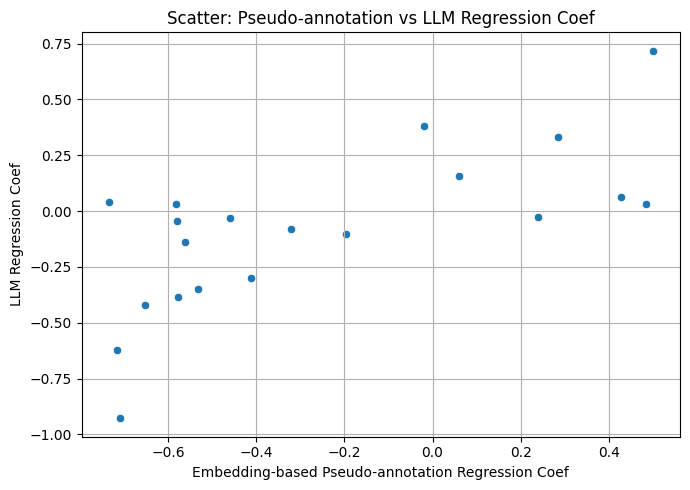

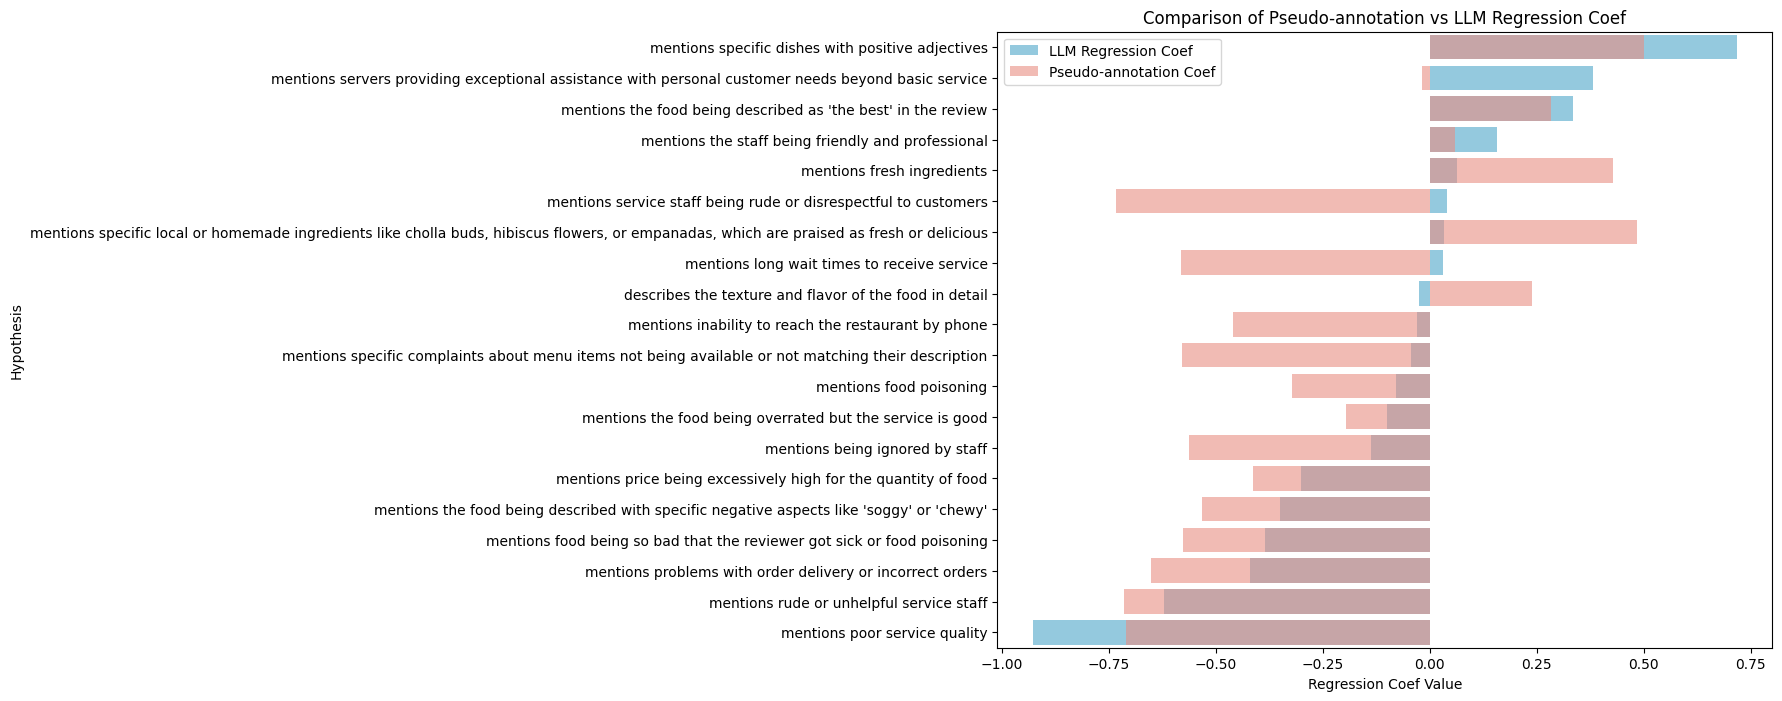

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Align the two datasets
# ------------------------------

# embedding-based pseudo-annotation
pseudo_series = evaluation_df_emb_scaled.set_index('hypothesis')['regression_coef']
pseudo_series.index = pseudo_series.index.str.strip()

# LLM-based regression coefficients
llm_series = evaluation_df.set_index('hypothesis')['regression_coef']
llm_series.index = llm_series.index.str.strip()

# Take common hypotheses
common_hypotheses = pseudo_series.index.intersection(llm_series.index)
print(f"Number of common hypotheses: {len(common_hypotheses)}")

pseudo_vals = pseudo_series[common_hypotheses].values
llm_vals = llm_series[common_hypotheses].values

# ------------------------------
# 2. Compute Pearson correlation
# ------------------------------
corr, pval = pearsonr(pseudo_vals, llm_vals)
print(f"Pearson correlation between pseudo-annotations and LLM regression_coef: {corr:.3f} (p={pval:.3e})")

# ------------------------------
# 3. Visualization
# ------------------------------

plot_df = pd.DataFrame({
    'hypothesis': common_hypotheses,
    'pseudo_annotation': pseudo_vals,
    'llm_regression_coef': llm_vals
})

# Scatter plot
plt.figure(figsize=(7,5))
sns.scatterplot(data=plot_df, x='pseudo_annotation', y='llm_regression_coef')
plt.xlabel("Embedding-based Pseudo-annotation Regression Coef")
plt.ylabel("LLM Regression Coef")
plt.title("Scatter Plot: Pseudo-annotation vs LLM Regression Coef")
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar plot: side-by-side comparison
plot_df_sorted = plot_df.sort_values(by='llm_regression_coef', ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(
    x='llm_regression_coef', y='hypothesis', data=plot_df_sorted,
    color='skyblue', label='LLM Regression Coef'
)
sns.barplot(
    x='pseudo_annotation', y='hypothesis', data=plot_df_sorted,
    color='salmon', alpha=0.6, label='Pseudo-annotation Coef'
)
plt.xlabel("Regression Coefficient Value")
plt.ylabel("Hypothesis")
plt.title("Comparison of Pseudo-annotation vs LLM Regression Coef")
plt.legend()
plt.tight_layout()
plt.show()
